# Problem Formulation and Limitation Audit

This notebook critically evaluates the current formulation of the learning-based algorithm selection problem.

The analysis focuses on:

1. whether the current solver portfolio creates a meaningful selection problem;
2. the sensitivity of labels to the runtime trade-off parameter;
3. possible shortcut relationships between instance size and solver labels;
4. the stability and practical interpretation of the current target;
5. limitations that should be addressed before further model development.

In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
current_dir = Path.cwd().resolve()

if (current_dir / "results").exists():
    project_root = current_dir
elif (current_dir.parent / "results").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the results directory."
    )

solver_path = project_root / "results" / "solver_results_v2.csv"
ml_path = project_root / "results" / "algorithm_selection_dataset.csv"

solver_df = pd.read_csv(solver_path)
ml_df = pd.read_csv(ml_path)

print("Project root:", project_root)
print("Solver results shape:", solver_df.shape)
print("ML dataset shape:", ml_df.shape)

Project root: D:\Github repository\uncertainty-aware-algorithm-selection
Solver results shape: (500, 10)
ML dataset shape: (500, 10)


## 1. Data Integrity Check

Before analysing the formulation, the consistency of the solver results
and machine-learning dataset is verified.

In [77]:
integrity_summary = pd.Series({
    "solver_rows": len(solver_df),
    "ml_rows": len(ml_df),
    "solver_missing_values": solver_df.isna().sum().sum(),
    "ml_missing_values": ml_df.isna().sum().sum(),
    "duplicate_solver_ids": solver_df["id"].duplicated().sum(),
    "expected_sequential_ids": (
        solver_df["id"].to_numpy()
        == np.arange(len(solver_df))
    ).all()
})

integrity_summary

solver_rows                 500
ml_rows                     500
solver_missing_values         0
ml_missing_values             0
duplicate_solver_ids          0
expected_sequential_ids    True
dtype: object

In [78]:
alignment_check = pd.DataFrame({
    "solver_n_items": solver_df["n_items"],
    "ml_n_items": ml_df["n_items"],
    "solver_correlation": solver_df["correlation"],
    "ml_correlation": ml_df["correlation"]
})

print(
    "n_items aligned:",
    (alignment_check["solver_n_items"]
     == alignment_check["ml_n_items"]).all()
)

print(
    "correlation aligned:",
    (alignment_check["solver_correlation"]
     == alignment_check["ml_correlation"]).all()
)

n_items aligned: True
correlation aligned: True


## 2. Solution-Quality Difference

Dynamic programming always provides an optimal solution in the current
setting. However, the practical value of algorithm selection depends on
whether the greedy heuristic produces meaningfully different solutions.

In [79]:
gap_summary = solver_df["gap"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

gap_summary

count    500.000000
mean       0.003146
std        0.005133
min        0.000000
25%        0.000000
50%        0.001016
75%        0.003584
90%        0.009547
95%        0.014337
max        0.032911
Name: gap, dtype: float64

In [80]:
quality_summary = pd.Series({
    "mean_gap_percent": solver_df["gap"].mean() * 100,
    "median_gap_percent": solver_df["gap"].median() * 100,
    "maximum_gap_percent": solver_df["gap"].max() * 100,
    "greedy_exact_count": (solver_df["gap"] == 0).sum(),
    "greedy_exact_rate_percent": (
        (solver_df["gap"] == 0).mean() * 100
    ),
    "gap_above_1_percent_count": (
        solver_df["gap"] > 0.01
    ).sum()
})

quality_summary

mean_gap_percent               0.314583
median_gap_percent             0.101617
maximum_gap_percent            3.291139
greedy_exact_count           140.000000
greedy_exact_rate_percent     28.000000
gap_above_1_percent_count     46.000000
dtype: float64

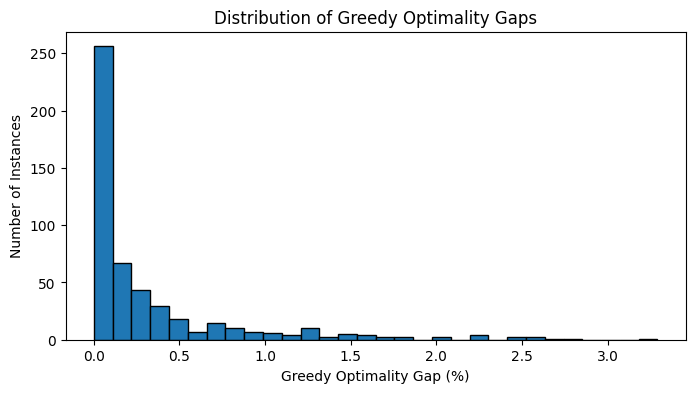

In [81]:
plt.figure(figsize=(8, 4))

plt.hist(
    solver_df["gap"] * 100,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Greedy Optimality Gap (%)")
plt.ylabel("Number of Instances")
plt.title("Distribution of Greedy Optimality Gaps")
plt.show()

### Preliminary Observation

The greedy heuristic is either optimal or very close to the dynamic
programming solution for a large proportion of the current instances.

This reduces the practical consequence of selecting the wrong solver.
A classifier may predict the preferred algorithm accurately without
producing a meaningful improvement in optimization performance.

Therefore, classification accuracy alone is insufficient for evaluating
the usefulness of the selector.

## 3. Sensitivity of the Cost-Aware Target

The current target is defined using:

$$
S_a = P_a - \lambda T_a
$$

where $$P_a\ and\ T_a\ $$ represent the profit and runtime of algorithm $$a\ $$ The following analysis recomputes the label distribution directly
from the solver results.

In [82]:
def generate_cost_aware_labels(df, lambda_runtime):
    greedy_score = (
        df["greedy_profit"]
        - lambda_runtime * df["greedy_time"]
    )

    dp_score = (
        df["dp_profit"]
        - lambda_runtime * df["dp_time"]
    )

    labels = np.where(
        greedy_score > dp_score,
        "greedy",
        "dp"
    )

    return pd.Series(
        labels,
        index=df.index,
        name="best_algorithm"
    )

In [83]:
lambda_values = [
    0,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    2000,
    5000
]

lambda_records = []

for lambda_runtime in lambda_values:
    labels = generate_cost_aware_labels(
        solver_df,
        lambda_runtime
    )

    counts = labels.value_counts()

    lambda_records.append({
        "lambda": lambda_runtime,
        "greedy": counts.get("greedy", 0),
        "dp": counts.get("dp", 0),
        "greedy_rate": (
            counts.get("greedy", 0) / len(labels)
        )
    })

lambda_df = pd.DataFrame(lambda_records)

lambda_df

,lambda,greedy,dp,greedy_rate
0,0,0,500,0.000
1,10,181,319,0.362
2,25,222,278,0.444
3,50,282,218,0.564
4,100,331,169,0.662
5,250,402,98,0.804
6,500,439,61,0.878
7,1000,474,26,0.948
8,2000,491,9,0.982
9,5000,500,0,1.000


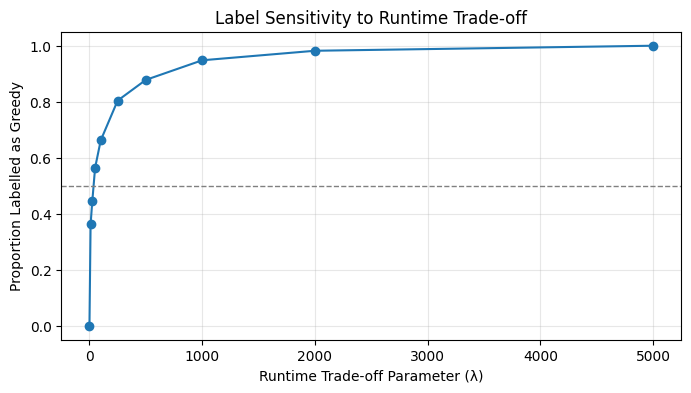

In [84]:
plt.figure(figsize=(8, 4))

plt.plot(
    lambda_df["lambda"],
    lambda_df["greedy_rate"],
    marker="o"
)

plt.axhline(
    0.5,
    color="grey",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Runtime Trade-off Parameter (λ)")
plt.ylabel("Proportion Labelled as Greedy")
plt.title("Label Sensitivity to Runtime Trade-off")
plt.grid(alpha=0.3)
plt.show()

### Preliminary Observation

The class distribution changes substantially with the value of λ.
Therefore, the machine-learning target is not an inherent property of
an instance; it also reflects a user-defined preference between solution
quality and runtime.

A suitable research formulation must either justify λ using an
application-specific cost model or replace the weighted score with a
more interpretable decision criterion, such as a fixed runtime budget,
quality threshold, or selection regret.

## 4. Potential Shortcut Relationships

A useful algorithm selector should learn meaningful interactions between
problem characteristics and solver performance. If labels are largely
determined by problem size, a classifier may learn a simple threshold
rather than general algorithmic behaviour.

In [85]:
solver_audit = solver_df.copy()

solver_audit["label_lambda_100"] = (
    generate_cost_aware_labels(
        solver_audit,
        lambda_runtime=100
    )
)

size_label_table = pd.crosstab(
    solver_audit["n_items"],
    solver_audit["label_lambda_100"],
    margins=True
)

size_label_table

label_lambda_100,dp,greedy,All
n_items,,,
50,137,125,262
100,32,125,157
200,0,81,81
All,169,331,500


In [86]:
size_label_rate = pd.crosstab(
    solver_audit["n_items"],
    solver_audit["label_lambda_100"],
    normalize="index"
)

size_label_rate

label_lambda_100,dp,greedy
n_items,,
50,0.522901,0.477099
100,0.203822,0.796178
200,0.000000,1.000000


In [87]:
correlation_label_table = pd.crosstab(
    solver_audit["correlation"],
    solver_audit["label_lambda_100"],
    margins=True
)

correlation_label_table

label_lambda_100,dp,greedy,All
correlation,,,
inverse,14,106,120
strong,77,47,124
uncorrelated,33,102,135
weak,45,76,121
All,169,331,500


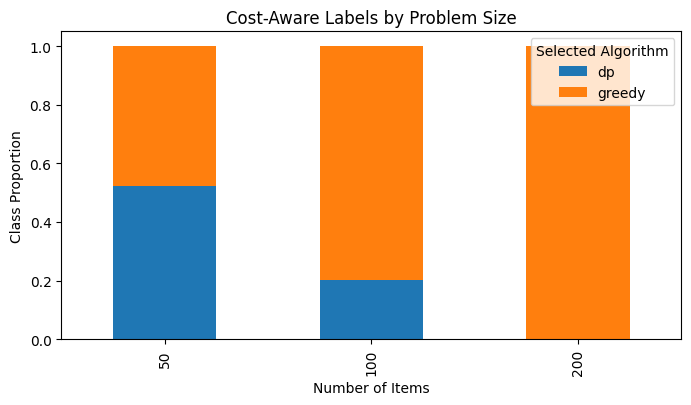

In [88]:
size_label_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.ylabel("Class Proportion")
plt.xlabel("Number of Items")
plt.title("Cost-Aware Labels by Problem Size")
plt.legend(title="Selected Algorithm")
plt.show()

### Preliminary Observation

At λ=100, all current instances with 200 items are labelled as greedy.
This indicates that problem size may act as a strong shortcut feature.

The existing machine-learning accuracy may therefore partly reflect the
ability to learn runtime thresholds associated with n_items rather than
a deeper relationship between instance structure and solver suitability.

In [89]:
lambda_runtime = 100

greedy_score = (
    solver_df["greedy_profit"]
    - lambda_runtime * solver_df["greedy_time"]
)

dp_score = (
    solver_df["dp_profit"]
    - lambda_runtime * solver_df["dp_time"]
)

score_margin = (greedy_score - dp_score).abs()

score_margin_summary = score_margin.describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

score_margin_summary

count    500.000000
mean      18.390176
std       23.470517
min        0.016620
10%        1.596385
25%        3.447058
50%        8.664120
75%       23.261208
90%       51.977652
max      118.362550
dtype: float64

In [90]:
margin_counts = pd.Series({
    "margin_below_1": (score_margin < 1).sum(),
    "margin_below_5": (score_margin < 5).sum(),
    "margin_below_10": (score_margin < 10).sum()
})

margin_counts

margin_below_1      29
margin_below_5     175
margin_below_10    267
dtype: int64

### Preliminary Observation

A substantial number of instances have small cost-aware score margins.
Since runtimes are currently measured only once, measurement noise could
change the preferred label for near-tie instances.

Runtime stability should therefore be evaluated using repeated
measurements, warm-up runs, and robust statistics such as the median
runtime.

## Preliminary Findings from the Formulation Audit

### Solution-quality difference

The greedy heuristic is optimal for 28% of the current instances.
Furthermore, only 9.2% of instances exhibit an optimality gap greater
than 1%.

This indicates that the practical consequence of selecting greedy
instead of dynamic programming is small for most current instances.
Therefore, classification accuracy alone may overstate the practical
value of the algorithm selector.

### Sensitivity to λ

The preferred-algorithm distribution changes substantially with the
runtime trade-off parameter. Hence, the current target is not an
intrinsic property of an instance; it also reflects a user-defined
preference between solution quality and runtime.

Selecting λ based primarily on class balance would not provide a
sufficient methodological justification.

### Shortcut relationships

Problem size has a strong relationship with the target. At λ=100, all
200-item instances are labelled as greedy.

However, the label distribution also differs across correlation
structures, suggesting that the target is not determined by problem
size alone.

### Potential label instability

A substantial number of instances have small cost-aware score margins.
Since each runtime is currently measured only once, near-tie labels may
be affected by runtime measurement noise.

Repeated timing experiments are required before drawing a final
conclusion about label stability.

## 5. Pareto Relationship between Solvers

Instead of immediately combining profit and runtime into a single
weighted score, the two objectives can first be examined separately.

An algorithm dominates another algorithm if it is at least as good in
both solution quality and runtime, and strictly better in at least one.

In [91]:
greedy_dominates = (
    (solver_df["greedy_profit"] >= solver_df["dp_profit"])
    &
    (solver_df["greedy_time"] <= solver_df["dp_time"])
    &
    (
        (solver_df["greedy_profit"] > solver_df["dp_profit"])
        |
        (solver_df["greedy_time"] < solver_df["dp_time"])
    )
)

dp_dominates = (
    (solver_df["dp_profit"] >= solver_df["greedy_profit"])
    &
    (solver_df["dp_time"] <= solver_df["greedy_time"])
    &
    (
        (solver_df["dp_profit"] > solver_df["greedy_profit"])
        |
        (solver_df["dp_time"] < solver_df["greedy_time"])
    )
)

trade_off = ~(greedy_dominates | dp_dominates)

pareto_summary = pd.Series({
    "greedy_dominates": greedy_dominates.sum(),
    "dp_dominates": dp_dominates.sum(),
    "quality_runtime_tradeoff": trade_off.sum()
})

pareto_summary

greedy_dominates            140
dp_dominates                  0
quality_runtime_tradeoff    360
dtype: int64

## 6. Quality-Tolerance Formulation

An alternative formulation is to predict whether the greedy solution
is sufficiently close to optimal.

For a selected tolerance ε, greedy is considered acceptable when:

$$
\frac{P_{\mathrm{DP}}-P_{\mathrm{Greedy}}}
{P_{\mathrm{DP}}}
\leq \epsilon
$$

This formulation is independent of hardware-specific runtime
measurements, although the choice of ε still requires an application
interpretation.

In [92]:
epsilon_values = [
    0.0,
    0.001,
    0.0025,
    0.005,
    0.01,
    0.02
]

epsilon_records = []

for epsilon in epsilon_values:
    greedy_acceptable = (
        solver_df["gap"] <= epsilon
    )

    epsilon_records.append({
        "epsilon": epsilon,
        "epsilon_percent": epsilon * 100,
        "greedy_acceptable": greedy_acceptable.sum(),
        "dp_required": (~greedy_acceptable).sum(),
        "greedy_acceptable_rate": greedy_acceptable.mean()
    })

epsilon_df = pd.DataFrame(epsilon_records)

epsilon_df

,epsilon,epsilon_percent,greedy_acceptable,dp_required,greedy_acceptable_rate
0,0.0000,0.00,140,360,0.280
1,0.0010,0.10,246,254,0.492
2,0.0025,0.25,337,163,0.674
3,0.0050,0.50,407,93,0.814
4,0.0100,1.00,454,46,0.908
5,0.0200,2.00,487,13,0.974


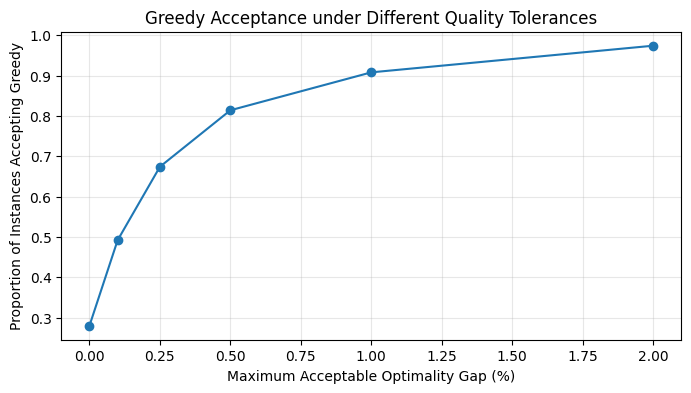

In [93]:
plt.figure(figsize=(8, 4))

plt.plot(
    epsilon_df["epsilon_percent"],
    epsilon_df["greedy_acceptable_rate"],
    marker="o"
)

plt.xlabel("Maximum Acceptable Optimality Gap (%)")
plt.ylabel("Proportion of Instances Accepting Greedy")
plt.title("Greedy Acceptance under Different Quality Tolerances")
plt.grid(alpha=0.3)
plt.show()

## 7. Normalized Cost-Aware Score Margin

The absolute score margin is affected by the scale of instance profits.
A normalized margin is therefore computed relative to the optimal
dynamic-programming profit.

In [94]:
lambda_runtime = 100

greedy_score = (
    solver_df["greedy_profit"]
    - lambda_runtime * solver_df["greedy_time"]
)

dp_score = (
    solver_df["dp_profit"]
    - lambda_runtime * solver_df["dp_time"]
)

normalized_score_margin = (
    (greedy_score - dp_score).abs()
    / solver_df["dp_profit"]
)

normalized_margin_summary = (
    normalized_score_margin * 100
).describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

normalized_margin_summary

count    500.000000
mean       0.407001
std        0.448759
min        0.000635
10%        0.074952
25%        0.140246
50%        0.258286
75%        0.523309
90%        0.866966
max        3.175938
dtype: float64

In [95]:
normalized_margin_counts = pd.Series({
    "below_0.01_percent": (
        normalized_score_margin < 0.0001
    ).sum(),

    "below_0.05_percent": (
        normalized_score_margin < 0.0005
    ).sum(),

    "below_0.10_percent": (
        normalized_score_margin < 0.001
    ).sum(),

    "below_0.25_percent": (
        normalized_score_margin < 0.0025
    ).sum(),

    "below_0.50_percent": (
        normalized_score_margin < 0.005
    ).sum()
})

normalized_margin_counts

below_0.01_percent      6
below_0.05_percent     32
below_0.10_percent     82
below_0.25_percent    245
below_0.50_percent    368
dtype: int64

In [96]:
joint_label_table = pd.crosstab(
    [
        solver_audit["n_items"],
        solver_audit["correlation"]
    ],
    solver_audit["label_lambda_100"]
)

joint_label_table

label_lambda_100      dp  greedy
n_items correlation             
50      inverse       10      47
        strong        63       6
        uncorrelated  26      48
        weak          38      24
100     inverse        4      37
        strong        14      18
        uncorrelated   7      37
        weak           7      33
200     inverse        0      22
        strong         0      23
        uncorrelated   0      17
        weak           0      19

In [97]:
joint_label_rate = pd.crosstab(
    [
        solver_audit["n_items"],
        solver_audit["correlation"]
    ],
    solver_audit["label_lambda_100"],
    normalize="index"
)

joint_label_rate

label_lambda_100            dp    greedy
n_items correlation                     
50      inverse       0.175439  0.824561
        strong        0.913043  0.086957
        uncorrelated  0.351351  0.648649
        weak          0.612903  0.387097
100     inverse       0.097561  0.902439
        strong        0.437500  0.562500
        uncorrelated  0.159091  0.840909
        weak          0.175000  0.825000
200     inverse       0.000000  1.000000
        strong        0.000000  1.000000
        uncorrelated  0.000000  1.000000
        weak          0.000000  1.000000

## Interpretation of the Extended Audit

The current problem is not entirely trivial. Among 500 instances,
360 exhibit a genuine trade-off in which dynamic programming provides
higher solution quality while greedy provides lower runtime.

However, the practical differences are generally small. At a 1%
optimality tolerance, greedy is acceptable for 90.8% of instances.
Furthermore, the normalized cost-aware score margin is below 0.5% for
most instances.

The joint label analysis shows that correlation structure influences
solver preference for smaller instances. In particular, strongly
correlated 50-item instances frequently favour dynamic programming.
Nevertheless, runtime dominates at larger scales: all 200-item
instances are labelled as greedy regardless of correlation structure.

These findings suggest that the current benchmark contains meaningful
structural signals, but the final label remains highly dependent on the
selected trade-off parameter and problem scale. The existing
classification accuracy should therefore not be interpreted as
sufficient evidence of practical algorithm-selection value.

## 8. Runtime Stability Experiment

The current cost-aware labels are based on a single runtime measurement
for each solver. Since execution time may vary between runs, a repeated
timing experiment is conducted to examine whether near-boundary labels
are stable.

Instances are selected from three groups:

- small normalized score margin;
- medium normalized score margin;
- large normalized score margin.

Each selected instance is evaluated repeatedly using the same hardware
and software environment.

In [98]:
import pickle
import sys

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from solvers import greedy_solver, dp_solver

with open(
    project_root / "data" / "knapsack_dataset_v2.pkl",
    "rb"
) as file:
    instances = pickle.load(file)

print("Loaded instances:", len(instances))

Loaded instances: 500


In [99]:
margin_df = pd.DataFrame({
    "id": solver_df["id"],
    "normalized_margin": normalized_score_margin,
    "original_n_items": solver_df["n_items"],
    "original_correlation": solver_df["correlation"]
}).sort_values(
    "normalized_margin"
).reset_index(drop=True)

margin_df.head()

,id,normalized_margin,original_n_items,original_correlation
0,203,0.000006,50,weak
1,268,0.000031,100,strong
2,395,0.000058,50,inverse
3,26,0.000059,50,strong
4,307,0.000067,50,inverse


In [100]:
near_ids = (
    margin_df
    .head(15)["id"]
    .tolist()
)

middle_start = len(margin_df) // 2 - 7

middle_ids = (
    margin_df
    .iloc[middle_start:middle_start + 15]["id"]
    .tolist()
)

far_ids = (
    margin_df
    .tail(15)["id"]
    .tolist()
)

selected_instances = pd.DataFrame({
    "id": near_ids + middle_ids + far_ids,
    "margin_group": (
        ["near"] * len(near_ids)
        + ["middle"] * len(middle_ids)
        + ["far"] * len(far_ids)
    )
})

selected_instances

,id,margin_group
0,203,near
1,268,near
2,395,near
3,26,near
4,307,near
5,6,near
6,475,near
7,241,near
8,23,near
9,214,near


In [101]:
lambda_runtime = 100
n_repeats = 10

timing_records = []

for _, selected_row in selected_instances.iterrows():
    instance_id = int(selected_row["id"])
    margin_group = selected_row["margin_group"]

    instance = instances[instance_id]

    # Warm-up runs are discarded.
    greedy_solver(instance)
    dp_solver(instance)

    for repetition in range(n_repeats):

        # Alternate execution order to reduce systematic ordering effects.
        if repetition % 2 == 0:
            greedy_result = greedy_solver(instance)
            dp_result = dp_solver(instance)
        else:
            dp_result = dp_solver(instance)
            greedy_result = greedy_solver(instance)

        greedy_score_repeat = (
            greedy_result["profit"]
            - lambda_runtime * greedy_result["runtime"]
        )

        dp_score_repeat = (
            dp_result["profit"]
            - lambda_runtime * dp_result["runtime"]
        )

        selected_algorithm = (
            "greedy"
            if greedy_score_repeat > dp_score_repeat
            else "dp"
        )

        timing_records.append({
            "id": instance_id,
            "margin_group": margin_group,
            "repetition": repetition,
            "n_items": len(instance["weights"]),
            "correlation": instance["correlation"],
            "greedy_profit": greedy_result["profit"],
            "dp_profit": dp_result["profit"],
            "greedy_time": greedy_result["runtime"],
            "dp_time": dp_result["runtime"],
            "greedy_score": greedy_score_repeat,
            "dp_score": dp_score_repeat,
            "selected_algorithm": selected_algorithm
        })

    print(
        f"Completed instance {instance_id} "
        f"({margin_group})"
    )

timing_df = pd.DataFrame(timing_records)

timing_df.shape

Completed instance 203 (near)
Completed instance 268 (near)
Completed instance 395 (near)
Completed instance 26 (near)
Completed instance 307 (near)
Completed instance 6 (near)
Completed instance 475 (near)
Completed instance 241 (near)
Completed instance 23 (near)
Completed instance 214 (near)
Completed instance 462 (near)
Completed instance 360 (near)
Completed instance 70 (near)
Completed instance 189 (near)
Completed instance 385 (near)
Completed instance 424 (middle)
Completed instance 320 (middle)
Completed instance 394 (middle)
Completed instance 146 (middle)
Completed instance 38 (middle)
Completed instance 434 (middle)
Completed instance 430 (middle)
Completed instance 250 (middle)
Completed instance 89 (middle)
Completed instance 447 (middle)
Completed instance 359 (middle)
Completed instance 261 (middle)
Completed instance 153 (middle)
Completed instance 436 (middle)
Completed instance 249 (middle)
Completed instance 93 (far)
Completed instance 479 (far)
Completed instance 1

(450, 12)

In [102]:
timing_summary = (
    timing_df
    .groupby(
        ["id", "margin_group"],
        as_index=False
    )
    .agg(
        n_items=("n_items", "first"),
        correlation=("correlation", "first"),

        greedy_time_median=(
            "greedy_time",
            "median"
        ),

        dp_time_median=(
            "dp_time",
            "median"
        ),

        greedy_time_mean=(
            "greedy_time",
            "mean"
        ),

        dp_time_mean=(
            "dp_time",
            "mean"
        ),

        greedy_time_std=(
            "greedy_time",
            "std"
        ),

        dp_time_std=(
            "dp_time",
            "std"
        ),

        greedy_label_rate=(
            "selected_algorithm",
            lambda values: (
                values == "greedy"
            ).mean()
        )
    )
)

In [103]:
timing_summary["label_stability"] = (
    timing_summary["greedy_label_rate"]
    .apply(
        lambda rate: max(
            rate,
            1 - rate
        )
    )
)

timing_summary["majority_label"] = np.where(
    timing_summary["greedy_label_rate"] >= 0.5,
    "greedy",
    "dp"
)

In [104]:
original_labels = generate_cost_aware_labels(
    solver_df,
    lambda_runtime=100
)

original_label_map = dict(
    zip(
        solver_df["id"],
        original_labels
    )
)

timing_summary["original_label"] = (
    timing_summary["id"]
    .map(original_label_map)
)

timing_summary["majority_differs_from_original"] = (
    timing_summary["majority_label"]
    != timing_summary["original_label"]
)

timing_summary.sort_values(
    [
        "label_stability",
        "margin_group"
    ]
).head(20)

,id,margin_group,n_items,correlation,greedy_time_median,dp_time_median,greedy_time_mean,dp_time_mean,greedy_time_std,dp_time_std,greedy_label_rate,label_stability,majority_label,original_label,majority_differs_from_original
6,93,far,50,strong,0.000044,0.024614,0.000037,0.024845,0.000014,0.001311,0.0,1.0,dp,dp,False
7,94,far,50,strong,0.000037,0.013076,0.000030,0.013205,0.000012,0.000503,0.0,1.0,dp,dp,False
8,99,far,50,uncorrelated,0.000028,0.003019,0.000041,0.003055,0.000045,0.000117,0.0,1.0,dp,dp,False
9,101,far,50,uncorrelated,0.000032,0.008653,0.000027,0.008816,0.000010,0.000551,0.0,1.0,dp,dp,False
10,128,far,50,strong,0.000033,0.006405,0.000034,0.006958,0.000016,0.001377,0.0,1.0,dp,dp,False
21,304,far,50,weak,0.000025,0.004298,0.000022,0.004348,0.000007,0.000161,0.0,1.0,dp,dp,False
23,317,far,50,strong,0.000034,0.008684,0.000030,0.008614,0.000012,0.000625,0.0,1.0,dp,dp,False
25,342,far,50,strong,0.000021,0.002697,0.000028,0.002660,0.000025,0.000196,0.0,1.0,dp,dp,False
31,401,far,50,strong,0.000030,0.006674,0.000034,0.006919,0.000025,0.000640,0.0,1.0,dp,dp,False
32,403,far,50,strong,0.000037,0.011295,0.000035,0.011521,0.000015,0.000700,0.0,1.0,dp,dp,False


In [105]:
stability_by_group = (
    timing_summary
    .groupby("margin_group")
    .agg(
        number_of_instances=(
            "id",
            "count"
        ),

        median_label_stability=(
            "label_stability",
            "median"
        ),

        unstable_below_90_percent=(
            "label_stability",
            lambda values: (
                values < 0.9
            ).sum()
        ),

        majority_label_changed=(
            "majority_differs_from_original",
            "sum"
        )
    )
)

stability_by_group

,number_of_instances,median_label_stability,unstable_below_90_percent,majority_label_changed
margin_group,,,,
far,15,1.0,0,0
middle,15,1.0,0,0
near,15,1.0,0,6


In [106]:
unstable_instances = (
    timing_summary[
        (
            timing_summary["label_stability"] < 0.9
        )
        |
        (
            timing_summary[
                "majority_differs_from_original"
            ]
        )
    ]
    .sort_values("label_stability")
)

unstable_instances

,id,margin_group,n_items,correlation,greedy_time_median,dp_time_median,greedy_time_mean,dp_time_mean,greedy_time_std,dp_time_std,greedy_label_rate,label_stability,majority_label,original_label,majority_differs_from_original
0,6,near,50,weak,0.000034,0.014106,0.000029,0.014089,0.000012,0.000362,0.0,1.0,dp,greedy,True
1,23,near,100,uncorrelated,0.000061,0.087499,0.000062,0.084267,0.000023,0.012604,0.0,1.0,dp,greedy,True
4,70,near,100,inverse,0.000059,0.023737,0.000055,0.025568,0.000026,0.003108,0.0,1.0,dp,greedy,True
15,214,near,100,inverse,0.000065,0.023013,0.000084,0.023982,0.000059,0.004131,0.0,1.0,dp,greedy,True
27,360,near,50,weak,0.000051,0.042294,0.000043,0.042213,0.000020,0.004168,0.0,1.0,dp,greedy,True
43,475,near,100,inverse,0.000053,0.028359,0.000074,0.028457,0.000075,0.000530,0.0,1.0,dp,greedy,True


In [109]:
protocol_sensitive_instances = timing_summary[
    timing_summary["majority_differs_from_original"]
].copy()

protocol_sensitive_instances

,id,margin_group,n_items,correlation,greedy_time_median,dp_time_median,greedy_time_mean,dp_time_mean,greedy_time_std,dp_time_std,greedy_label_rate,label_stability,majority_label,original_label,majority_differs_from_original
0,6,near,50,weak,0.000034,0.014106,0.000029,0.014089,0.000012,0.000362,0.0,1.0,dp,greedy,True
1,23,near,100,uncorrelated,0.000061,0.087499,0.000062,0.084267,0.000023,0.012604,0.0,1.0,dp,greedy,True
4,70,near,100,inverse,0.000059,0.023737,0.000055,0.025568,0.000026,0.003108,0.0,1.0,dp,greedy,True
15,214,near,100,inverse,0.000065,0.023013,0.000084,0.023982,0.000059,0.004131,0.0,1.0,dp,greedy,True
27,360,near,50,weak,0.000051,0.042294,0.000043,0.042213,0.000020,0.004168,0.0,1.0,dp,greedy,True
43,475,near,100,inverse,0.000053,0.028359,0.000074,0.028457,0.000075,0.000530,0.0,1.0,dp,greedy,True


In [110]:
original_times = solver_df[
    [
        "id",
        "greedy_time",
        "dp_time"
    ]
].rename(
    columns={
        "greedy_time": "greedy_time_original",
        "dp_time": "dp_time_original"
    }
)

runtime_comparison = protocol_sensitive_instances.merge(
    original_times,
    on="id",
    how="left"
)

runtime_comparison["greedy_time_ratio"] = (
    runtime_comparison["greedy_time_median"]
    / runtime_comparison["greedy_time_original"]
)

runtime_comparison["dp_time_ratio"] = (
    runtime_comparison["dp_time_median"]
    / runtime_comparison["dp_time_original"]
)

runtime_comparison["greedy_time_change_ms"] = 1000 * (
    runtime_comparison["greedy_time_median"]
    - runtime_comparison["greedy_time_original"]
)

runtime_comparison["dp_time_change_ms"] = 1000 * (
    runtime_comparison["dp_time_median"]
    - runtime_comparison["dp_time_original"]
)

runtime_comparison[
    [
        "id",
        "n_items",
        "correlation",
        "original_label",
        "majority_label",
        "greedy_time_original",
        "greedy_time_median",
        "greedy_time_ratio",
        "dp_time_original",
        "dp_time_median",
        "dp_time_ratio",
        "dp_time_change_ms"
    ]
]

,id,n_items,correlation,original_label,majority_label,greedy_time_original,greedy_time_median,greedy_time_ratio,dp_time_original,dp_time_median,dp_time_ratio,dp_time_change_ms
0,6,50,weak,greedy,dp,0.000082,0.000034,0.421472,0.031446,0.014106,0.448561,-17.34065
1,23,100,uncorrelated,greedy,dp,0.000099,0.000061,0.621964,0.136527,0.087499,0.640891,-49.02830
2,70,100,inverse,greedy,dp,0.000104,0.000059,0.570260,0.049299,0.023737,0.481489,-25.56185
3,214,100,inverse,greedy,dp,0.000111,0.000065,0.583108,0.047865,0.023013,0.480792,-24.85165
4,360,50,weak,greedy,dp,0.000079,0.000051,0.647914,0.068867,0.042294,0.614143,-26.57280
5,475,100,inverse,greedy,dp,0.000097,0.000053,0.546344,0.063993,0.028359,0.443150,-35.63450


In [111]:
runtime_comparison[
    [
        "greedy_time_ratio",
        "dp_time_ratio",
        "greedy_time_change_ms",
        "dp_time_change_ms"
    ]
].describe()

,greedy_time_ratio,dp_time_ratio,greedy_time_change_ms,dp_time_change_ms
count,6.000000,6.000000,6.000000,6.000000
mean,0.565177,0.518171,-0.041200,-29.831625
std,0.079276,0.086588,0.007389,11.062199
min,0.421472,0.443150,-0.047150,-49.028300
25%,0.552323,0.456619,-0.045775,-33.369075
50%,0.576684,0.481140,-0.044350,-26.067325
75%,0.612250,0.580979,-0.039025,-25.029200
max,0.647914,0.640891,-0.027850,-17.340650


In [112]:
within_session_unstable = timing_summary[
    timing_summary["label_stability"] < 0.9
].copy()

protocol_sensitive_instances = timing_summary[
    timing_summary["majority_differs_from_original"]
].copy()

print(
    "Within-session unstable instances:",
    len(within_session_unstable)
)

print(
    "Protocol-sensitive instances:",
    len(protocol_sensitive_instances)
)

Within-session unstable instances: 0
Protocol-sensitive instances: 6


## Runtime Benchmarking Conclusions

Repeated measurements were internally stable: all 45 selected
instances produced the same algorithm label across the repeated trials.

However, 6 of the 15 near-margin instances changed from Greedy to
Dynamic Programming when repeated median runtimes were used instead
of the original single-run measurements. No changes occurred in the
middle- or far-margin groups.

Both solvers were faster under the repeated benchmarking protocol.
The median DP runtime for the six changed instances was approximately
52% of the original measurement, while the median Greedy runtime was
approximately 57% of its original measurement. Because the cost-aware
objective uses absolute runtime, the much larger absolute reduction in
DP runtime was sufficient to change decisions close to the boundary.

This demonstrates that the original single-run labels are sensitive
to the benchmarking environment and protocol. Although runtime remains
an important decision criterion, raw wall-clock time should not be
treated as an intrinsic instance label.

If this direction is retained, future work should use a standardized
repeated-timing protocol and a more interpretable decision formulation,
such as selecting the fastest solver subject to a specified relative
solution-quality tolerance.